# Reproducing Paper Results

**Paper:** A Computational Account of Epistemic Vigilance: Learning from Selective Truths through Bayesian Reasoning

This notebook reproduces the key figures from the paper:
- **Figure 1:** Speaker utterance preferences P(u|O) across speaker types and observations
- **Figure 2:** Listener posterior beliefs after hearing 'some, effective'
- **Figure 3:** Theta learning across speaker types (dyadic interactions)
- **Figure 4:** Speaker type learning by vigilant listeners
- **Figures 5-6:** Bias and uncertainty analysis

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from rsa import *

## Figure 1: Speaker Utterance Preferences

P(u|O) for Literal S0, Informative S1, Persuasive-down S1, Persuasive-up S1
across observations: 0/7, 2/7, 4/7 effective sessions (n=1, m=7, α=3)

In [2]:
# Setup: n=1 patient, m=7 sessions, alpha=3
alpha = 3.0
agents = make_agents(theta=0.3, n=1, m=7, alpha=alpha, speaker_psi='inf', thetas = make_thetas(0.1, True, True))
s0, l0, s1 = agents['s0'], agents['l0'], agents['s1']
semantics = agents['semantics']

# Create all three speaker types using same lower-level agents
s1_inf = Speaker1(agents['thetas'], l0, semantics=semantics, world=agents['world'], alpha=alpha, psi='inf')
s1_pers_down = Speaker1(agents['thetas'], l0, semantics=semantics, world=agents['world'], alpha=alpha, psi='low')
s1_pers_up = Speaker1(agents['thetas'], l0, semantics=semantics, world=agents['world'], alpha=alpha, psi='high')

# Observations: 0/7, 2/7, 4/7 effective for single patient
# obs[k] = 1 means the patient had k effective sessions (n=1 so exactly one entry is 1)
obs_0_7 = tuple([1] + [0]*7)   # 0 effective
obs_2_7 = tuple([0,0,1] + [0]*5)  # 2 effective
obs_4_7 = tuple([0,0,0,0,1] + [0]*3)  # 4 effective

observations = [obs_0_7, obs_2_7, obs_4_7]
obs_labels = ['0/7 effective', '2/7 effective', '4/7 effective']
speakers = [('Literal (S₀)', s0), ('Informative (S₁)', s1_inf), 
            ('Persuasive ↓ (S₁)', s1_pers_down), ('Persuasive ↑ (S₁)', s1_pers_up)]

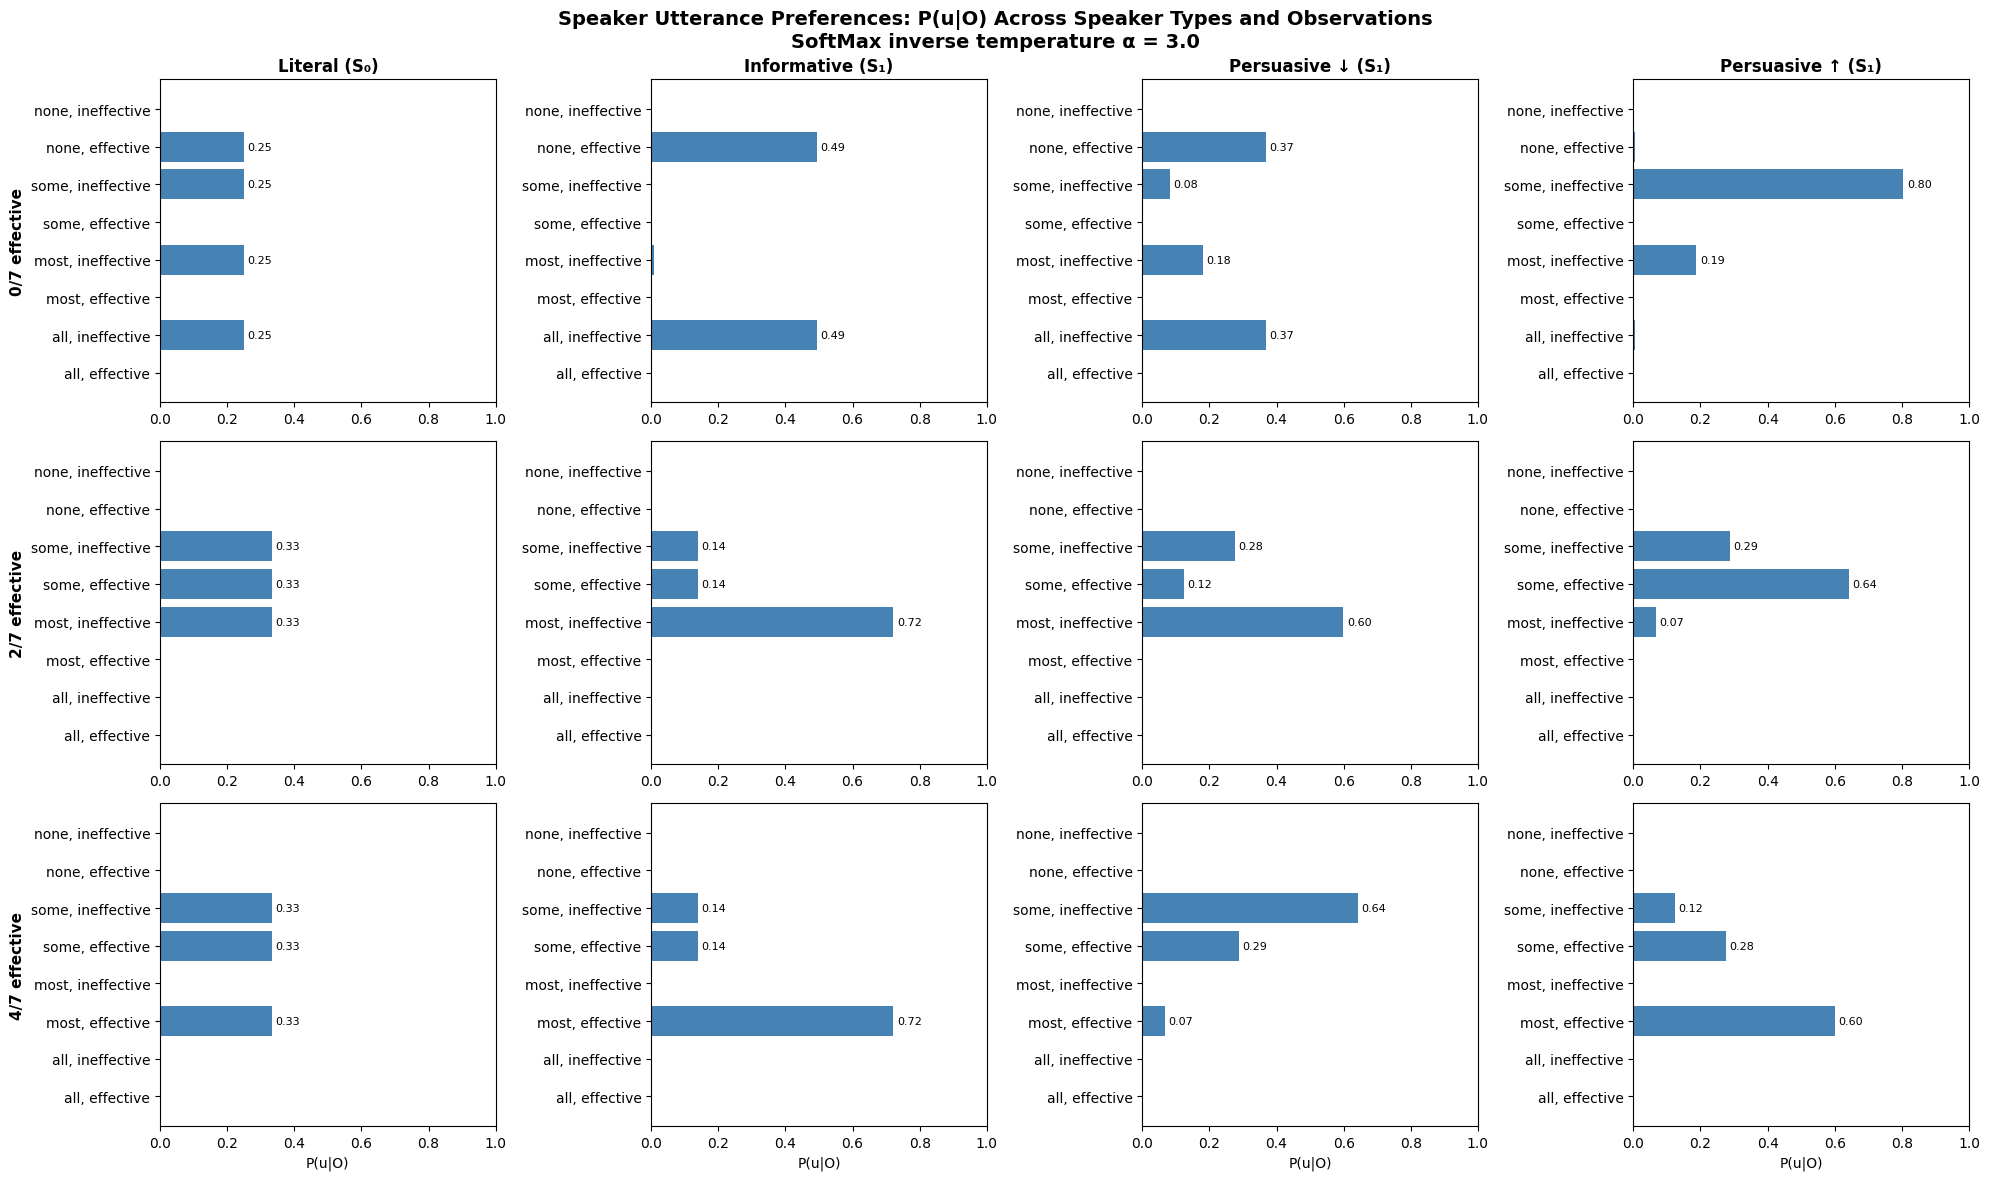

In [3]:
from rsa.utils import UTTERANCE_ORDER_SIMPLE

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for row, (obs, obs_label) in enumerate(zip(observations, obs_labels)):
    for col, (speaker_name, speaker) in enumerate(speakers):
        ax = axes[row, col]
        
        if isinstance(speaker, Speaker0):
            dist = speaker.dist_over_utterances_obs(obs)
        elif speaker_name.startswith('Informative'):
            dist = speaker.dist_over_utterances_obs(obs, 'inf')
        elif 'down' in speaker_name or '↓' in speaker_name:
            dist = speaker.dist_over_utterances_obs(obs, 'low')
        else:
            dist = speaker.dist_over_utterances_obs(obs, 'high')
        
        labels = [f"{q}, {p}" for (q, p) in UTTERANCE_ORDER_SIMPLE]
        probs = [dist.get((q, p), 0.0) for (q, p) in UTTERANCE_ORDER_SIMPLE]
        
        bars = ax.barh(labels, probs, color='steelblue')
        for bar, prob in zip(bars, probs):
            if prob > 0.01:
                ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                       f'{prob:.2f}', va='center', fontsize=8)
        ax.set_xlim(0, 1)
        ax.invert_yaxis()
        
        if row == 0:
            ax.set_title(speaker_name, fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(obs_label, fontsize=11, fontweight='bold')
        if row == 2:
            ax.set_xlabel('P(u|O)')

fig.suptitle(f'Speaker Utterance Preferences: P(u|O) Across Speaker Types and Observations\nSoftMax inverse temperature α = {alpha}',
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Figure 2: Listener Posterior Beliefs

Posterior P(θ|u) and P(ψ|u) after hearing 'some, effective' for:
- Literal Listener L0
- Credulous Pragmatic Listener L1-coop
- Vigilant Pragmatic Listener L1-strat

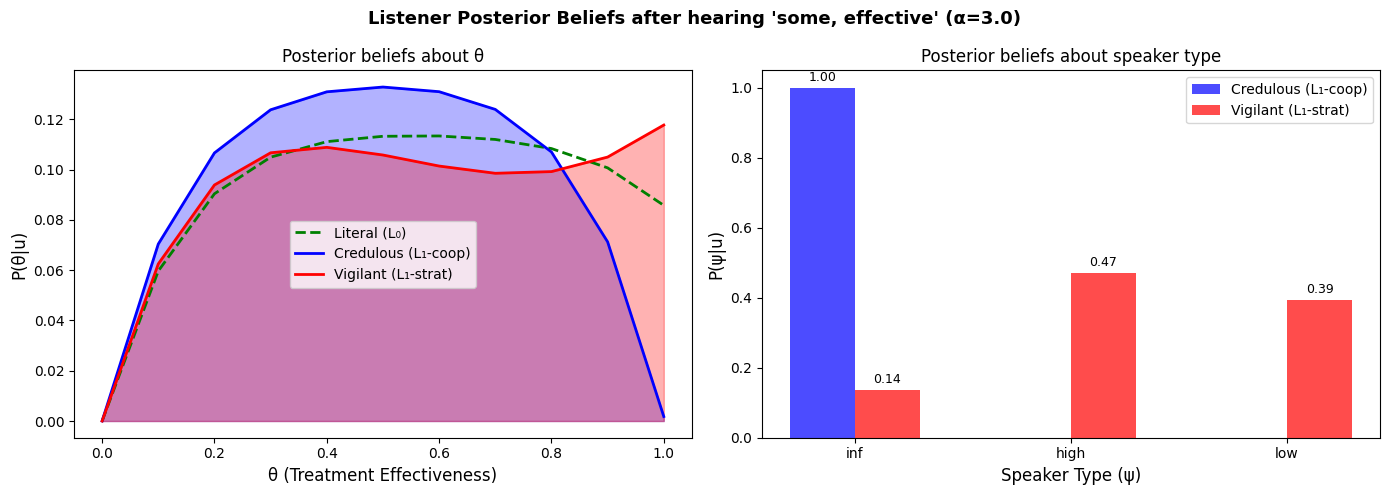

In [4]:
# Create credulous and vigilant listeners
psis = ['inf', 'high', 'low']
l1_coop = Listener1(agents['thetas'], psis, s1_inf, agents['world'], semantics, listener_type='inf', alpha=alpha)
l1_strat = Listener1(agents['thetas'], psis, s1_inf, agents['world'], semantics, listener_type='vig', alpha=alpha)

utt = ('some', 'effective')

# Get posteriors
l0_posterior = l0.infer_state(utt).as_dict()
l1_coop_posterior = l1_coop.infer_state(utt).marginal(0)
l1_strat_posterior = l1_strat.infer_state(utt).marginal(0)
l1_strat_psi = l1_strat.infer_state(utt).marginal(1)

# Plot theta posteriors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

thetas_sorted = sorted(l0_posterior.keys())
width = 0.025

ax1.plot(thetas_sorted, [l0_posterior[t] for t in thetas_sorted], 'g--', label='Literal (L₀)', linewidth=2)
ax1.fill_between(thetas_sorted, [l1_coop_posterior[t] for t in thetas_sorted], alpha=0.3, color='blue')
ax1.plot(thetas_sorted, [l1_coop_posterior[t] for t in thetas_sorted], 'b-', label='Credulous (L₁-coop)', linewidth=2)
ax1.fill_between(thetas_sorted, [l1_strat_posterior[t] for t in thetas_sorted], alpha=0.3, color='red')
ax1.plot(thetas_sorted, [l1_strat_posterior[t] for t in thetas_sorted], 'r-', label='Vigilant (L₁-strat)', linewidth=2)
ax1.set_xlabel('θ (Treatment Effectiveness)', fontsize=12)
ax1.set_ylabel('P(θ|u)', fontsize=12)
ax1.legend(fontsize=10)
ax1.set_title('Posterior beliefs about θ', fontsize=12)

# Plot psi posteriors (only for vigilant)
psi_labels = list(l1_strat_psi.keys())
psi_probs = [l1_strat_psi[p] for p in psi_labels]
# Also show L1-coop psi (should be all on 'inf')
l1_coop_psi = l1_coop.infer_state(utt).marginal(1)
coop_psi_probs = [l1_coop_psi.get(p, 0.0) for p in psi_labels]

x = np.arange(len(psi_labels))
ax2.bar(x - 0.15, coop_psi_probs, 0.3, label='Credulous (L₁-coop)', color='blue', alpha=0.7)
ax2.bar(x + 0.15, psi_probs, 0.3, label='Vigilant (L₁-strat)', color='red', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(psi_labels)
ax2.set_xlabel('Speaker Type (ψ)', fontsize=12)
ax2.set_ylabel('P(ψ|u)', fontsize=12)
ax2.legend(fontsize=10)
ax2.set_title('Posterior beliefs about speaker type', fontsize=12)

for i, (cp, vp) in enumerate(zip(coop_psi_probs, psi_probs)):
    if cp > 0.01: ax2.text(i - 0.15, cp + 0.02, f'{cp:.2f}', ha='center', fontsize=9)
    if vp > 0.01: ax2.text(i + 0.15, vp + 0.02, f'{vp:.2f}', ha='center', fontsize=9)

fig.suptitle(f"Listener Posterior Beliefs after hearing 'some, effective' (α={alpha})",
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Figures 3-4: Dyadic Interactions (Multi-round)

150-round dyadic interactions between speakers (inf, pers-) and listeners (coop, strat)
across θ = 0.1 to 0.9 with n=5, m=7.

In [5]:
# This cell runs the full dyadic simulation — may take a while for n=5, m=7
# Start with n=1, m=7 for quick testing, then switch to n=5, m=7 for paper figures

n_patients = 5  # Change to 5 for paper figure
m_sessions = 7
n_rounds = 150
n_trials = 1
alpha = 3.0
#theta_values = [0.1 * i for i in range(1, 10)]  # 0.1 to 0.9
theta_values = [0.7]
thetas = make_thetas(0.1, True, True)
psis = ['inf', 'high', 'low']

def mean_series(series_list):
    max_len = max(len(series) for series in series_list)
    means = []
    for t in range(max_len):
        values = [series[t] for series in series_list if t < len(series)]
        means.append(np.mean(values))
    return means

# Storage for results
results = {}  # (speaker_type, listener_type, theta) -> list of listener histories

for true_theta in theta_values:
    for speaker_type in ['low']:  # informative and persuasive-down
        for listener_type in ['inf','vig']:  # credulous and vigilant
            key = (speaker_type, listener_type, true_theta)
            trial_listeners = []
            for trial_idx in range(n_trials):
                world = make_world(true_theta, n=n_patients, m=m_sessions)
                semantics = make_semantics(n=n_patients)

                s1_agents, l1_agents, l0_agents, s0_agents = game_s1(
                    thetas, psis, semantics, world,
                    speaker_type=speaker_type, listener_type=listener_type,
                    alpha=alpha, rounds=n_rounds, verbose=False
                )
                trial_listeners.append(l1_agents)

            results[key] = trial_listeners
            print(
                f'Done: speaker={speaker_type}, listener={listener_type}, '
                f'θ={true_theta:.1f}, trials={n_trials}'
            )

Done: speaker=low, listener=inf, θ=0.7, trials=1
Done: speaker=low, listener=vig, θ=0.7, trials=1


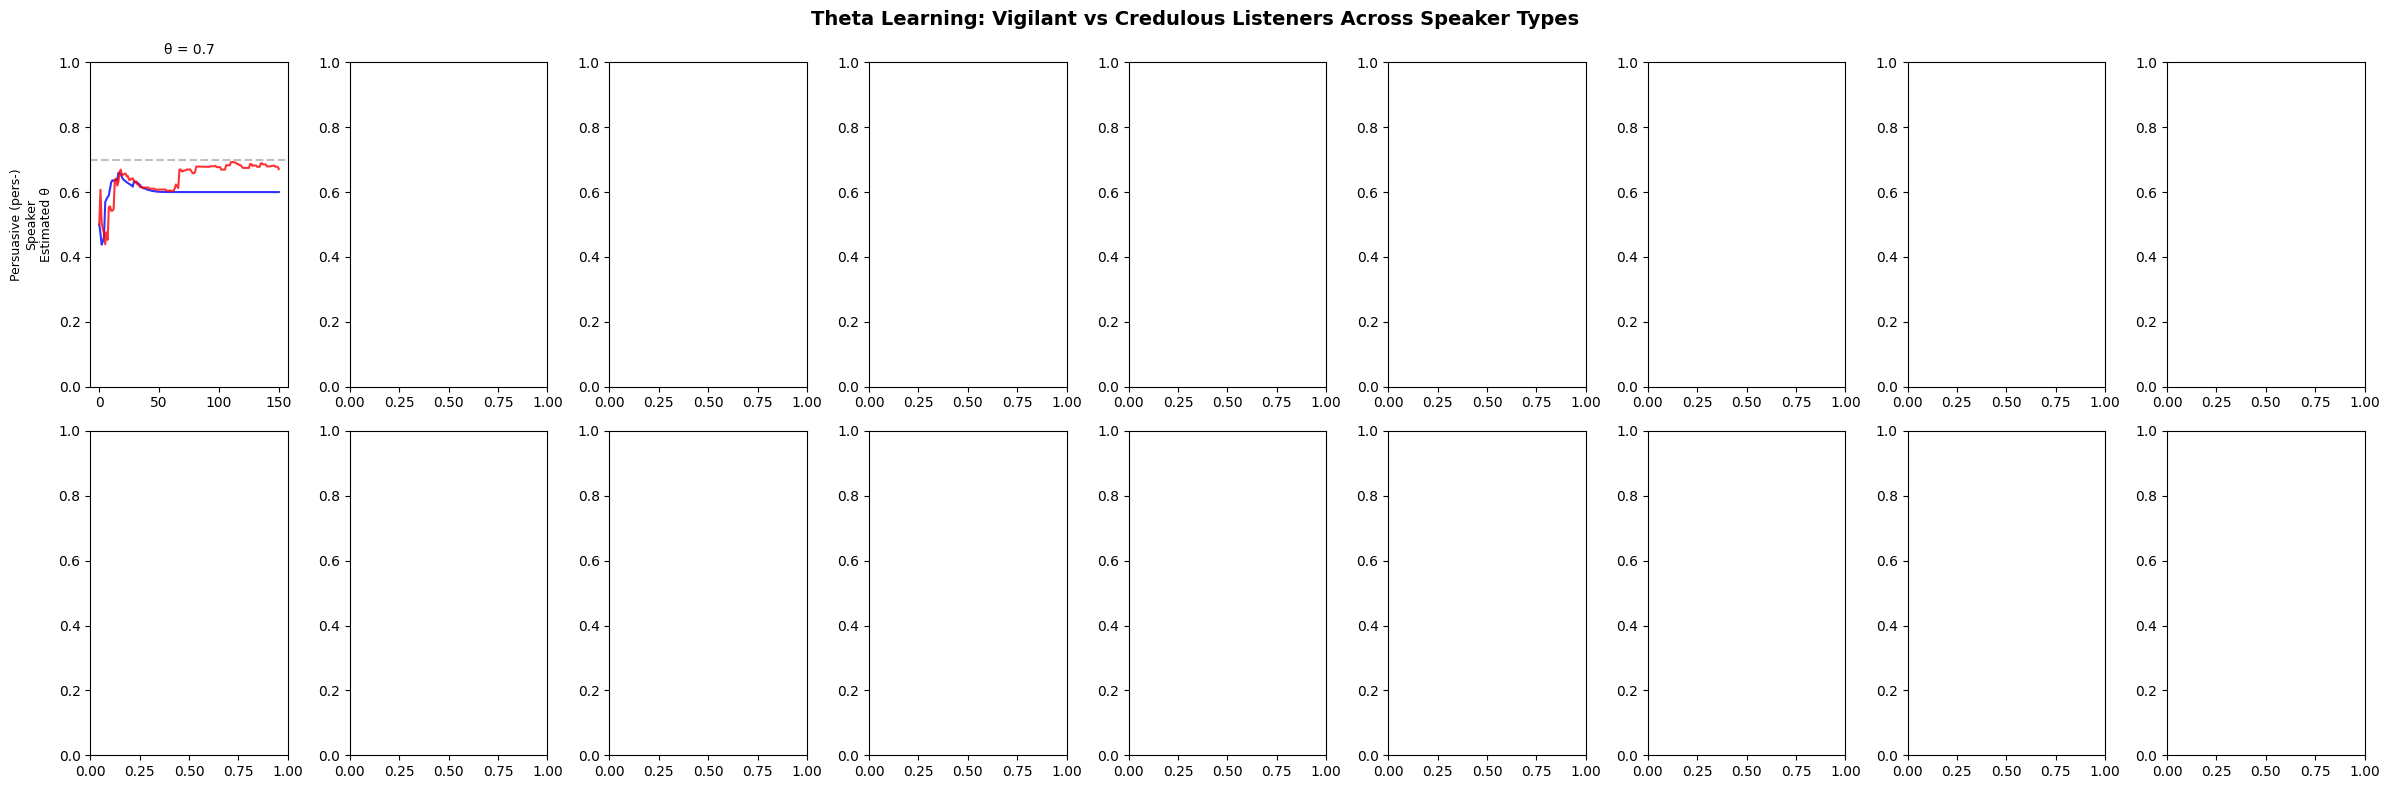

In [6]:
# Figure 3: Theta Learning
fig, axes = plt.subplots(2, 9, figsize=(24, 8))

for col, true_theta in enumerate(theta_values):
    for row, speaker_type in enumerate(['low']):
        ax = axes[row, col]
        
        for listener_type, color, label in [('inf', 'blue', 'Credulous'), ('vig', 'red', 'Vigilant')]:
            listeners = results[(speaker_type, listener_type, true_theta)]
            trajectories = []
            for listener in listeners:
                e_thetas = []
                for belief in listener.hist:
                    theta_dist = belief.marginal(0)
                    e_theta = sum(t * p for t, p in theta_dist.items())
                    e_thetas.append(e_theta)
                trajectories.append(e_thetas)
            ax.plot(mean_series(trajectories), color=color, label=label, alpha=0.8)
        
        ax.axhline(y=true_theta, color='gray', linestyle='--', alpha=0.5)
        ax.set_ylim(0, 1)
        
        if row == 0:
            ax.set_title(f'θ = {true_theta:.1f}', fontsize=10)
        if col == 0:
            speaker_label = 'Informative\nSpeaker' if speaker_type == 'inf' else 'Persuasive (pers-)\nSpeaker'
            ax.set_ylabel(f'{speaker_label}\nEstimated θ', fontsize=9)
        if row == 0 and col == 8:
            ax.legend(fontsize=8)

fig.suptitle('Theta Learning: Vigilant vs Credulous Listeners Across Speaker Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Figure 4: Speaker Type Learning (vigilant listeners only)
fig, axes = plt.subplots(2, 9, figsize=(24, 8))

for col, true_theta in enumerate(theta_values):
    for row, speaker_type in enumerate(['inf', 'low']):
        ax = axes[row, col]
        listeners = results[(speaker_type, 'vig', true_theta)]
        
        colors = {'low': 'blue', 'inf': 'green', 'high': 'red'}
        for psi in psis:
            psi_trajectories = []
            for listener in listeners:
                psi_history = []
                for belief in listener.hist:
                    psi_dist = belief.marginal(1)
                    psi_history.append(psi_dist.get(psi, 0.0))
                psi_trajectories.append(psi_history)
            ax.plot(mean_series(psi_trajectories), color=colors.get(psi, 'gray'), label=f'"{psi}"', alpha=0.8)
        
        ax.set_ylim(0, 1)
        if row == 0:
            ax.set_title(f'θ = {true_theta:.1f}', fontsize=10)
        if col == 0:
            speaker_label = 'Informative\nSpeaker' if speaker_type == 'inf' else 'Persuasive (pers-)\nSpeaker'
            ax.set_ylabel(f'{speaker_label}\nInference Freq', fontsize=9)
        if row == 0 and col == 8:
            ax.legend(fontsize=8)

fig.suptitle('Speaker Type Learning: How Vigilant Listeners Detect Speaker Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Figures 5-6: Bias and Uncertainty Analysis

Compute bias and standard deviation of theta estimates across rounds.

In [ ]:
# Extract bias and uncertainty metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, speaker_type in enumerate(['inf', 'low']):
    for listener_type, color, label in [('inf', 'blue', 'Credulous'), ('vig', 'red', 'Vigilant')]:
        biases = []
        stds = []
        
        for true_theta in theta_values:
            listeners = results[(speaker_type, listener_type, true_theta)]
            for listener in listeners:
                round_biases = []
                round_stds = []
                for belief in listener.hist:
                    theta_dist = belief.marginal(0)
                    e_theta = sum(t * p for t, p in theta_dist.items())
                    var_theta = sum((t - e_theta)**2 * p for t, p in theta_dist.items())
                    round_biases.append(e_theta - true_theta)
                    round_stds.append(np.sqrt(var_theta))
                biases.append(round_biases)
                stds.append(round_stds)
        
        # Mean absolute bias across thetas and trials
        max_len = max(len(b) for b in biases)
        mean_abs_bias = []
        mean_std = []
        for t in range(max_len):
            abs_b = [abs(biases[i][t]) for i in range(len(biases)) if t < len(biases[i])]
            s = [stds[i][t] for i in range(len(stds)) if t < len(stds[i])]
            mean_abs_bias.append(np.mean(abs_b))
            mean_std.append(np.mean(s))
        
        axes[0, col].plot(mean_abs_bias, color=color, label=f'{label} (mean |bias|)', linewidth=2)
        axes[1, col].plot(mean_std, color=color, label=f'{label} (mean std)', linewidth=2)
    
    speaker_label = 'Informative Speaker' if speaker_type == 'inf' else 'Persuasive Speaker'
    axes[0, col].set_title(speaker_label, fontsize=12, fontweight='bold')
    axes[0, col].set_ylabel('Mean |Bias|')
    axes[0, col].legend()
    axes[0, col].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
    axes[1, col].set_xlabel('Round')
    axes[1, col].set_ylabel('Mean Std Dev')
    axes[1, col].legend()

fig.suptitle('Bias and Uncertainty Analysis: Vigilant vs Credulous Listeners', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()